In [9]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [11]:
# Predicting the typical time gap between each event
median_ttns = y_train.median() #Finding the typical inter-event time gap
y_predicted_median =[median_ttns]*len(y_test) #Median predicition for each event in the list
MAE_median = mean_absolute_error(y_test, y_predicted_median) #Comparing how the median prediction comapares to the ML methods using mean absolute error
Median_Error = MAE_median #converting to multiplicative error since the MAE was based on a target column in the log space
print("Multiplicative Error for Median Baseline:", Median_Error)
#Error value in seconds for comaparison
y_test_secs_median = y_test #Taking it out of log scale
y_pred_secs_median = [y for y in y_predicted_median]

absolute_error_secs_median = np.abs(y_pred_secs_median - y_test_secs_median)
print("Average Error per Record for Median:", np.mean(absolute_error_secs_median))

# Presistence baseline; assuming the TTNS is the same as the previous one
# Using an array where the first column is the TTNS from the previous event and the second column is the actual TTNS for the that event
y_test_array = y_test.values
y_predicted_presist = y_test_array[:-1]
y_actual = y_test_array[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist #converting to multiplicative error since the MAE was based on a target column in the log space
print("Multiplicative Error for Presistent Baseline:", Presist_Error)

# Calculating error in seconds
y_test_secs_pre = np.array(y_test) #Taking it out of log scale
y_test_secs_pre = y_test_secs_pre[1:] #Dropping the first value to align with predictions (comparing y_t prediction to y_{t+1} actual)
y_pred_secs_pre = np.array(y_predicted_presist)

absolute_error_secs_pre = np.abs(y_pred_secs_pre - y_test_secs_pre)
print("Average Error per Record for Presistent:", np.mean(absolute_error_secs_pre))

Multiplicative Error for Median Baseline: 674.0595084087969
Average Error per Record for Median: 674.0595084087969
Multiplicative Error for Presistent Baseline: 808.8063471502591
Average Error per Record for Presistent: 808.8063471502591


Sample0: True = 665.00s, Predicted = 860.00s, Error=195.00s
Sample1: True = 897.75s, Predicted = 860.00s, Error=37.75s
Sample2: True = 1377.25s, Predicted = 860.00s, Error=517.25s
Sample3: True = 1545.00s, Predicted = 860.00s, Error=685.00s
Sample4: True = 1230.00s, Predicted = 860.00s, Error=370.00s
Sample5: True = 803.75s, Predicted = 860.00s, Error=56.25s
Sample6: True = 790.00s, Predicted = 860.00s, Error=70.00s
Sample7: True = 1196.25s, Predicted = 860.00s, Error=336.25s
Sample8: True = 920.00s, Predicted = 860.00s, Error=60.00s
Sample9: True = 715.00s, Predicted = 860.00s, Error=145.00s
Sample10: True = 1223.75s, Predicted = 860.00s, Error=363.75s
Sample11: True = 1396.25s, Predicted = 860.00s, Error=536.25s
Sample12: True = 1448.75s, Predicted = 860.00s, Error=588.75s
Sample13: True = 1446.25s, Predicted = 860.00s, Error=586.25s
Sample14: True = 1505.00s, Predicted = 860.00s, Error=645.00s
Sample15: True = 615.00s, Predicted = 860.00s, Error=245.00s
Sample16: True = 868.75s, Pre

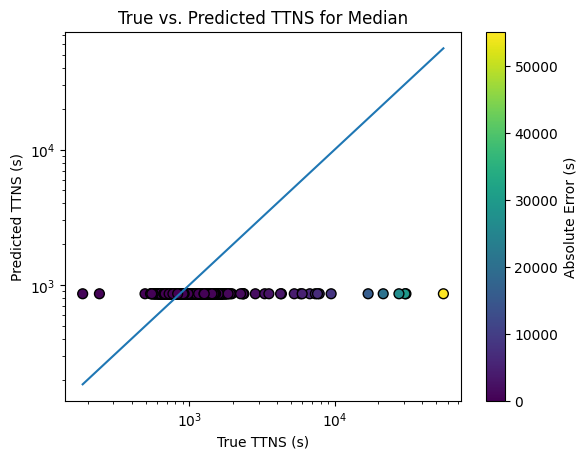

Sample0: True = 897.75s, Predicted = 665.00s, Error=232.75s
Sample1: True = 1377.25s, Predicted = 897.75s, Error=479.50s
Sample2: True = 1545.00s, Predicted = 1377.25s, Error=167.75s
Sample3: True = 1230.00s, Predicted = 1545.00s, Error=315.00s
Sample4: True = 803.75s, Predicted = 1230.00s, Error=426.25s
Sample5: True = 790.00s, Predicted = 803.75s, Error=13.75s
Sample6: True = 1196.25s, Predicted = 790.00s, Error=406.25s
Sample7: True = 920.00s, Predicted = 1196.25s, Error=276.25s
Sample8: True = 715.00s, Predicted = 920.00s, Error=205.00s
Sample9: True = 1223.75s, Predicted = 715.00s, Error=508.75s
Sample10: True = 1396.25s, Predicted = 1223.75s, Error=172.50s
Sample11: True = 1448.75s, Predicted = 1396.25s, Error=52.50s
Sample12: True = 1446.25s, Predicted = 1448.75s, Error=2.50s
Sample13: True = 1505.00s, Predicted = 1446.25s, Error=58.75s
Sample14: True = 615.00s, Predicted = 1505.00s, Error=890.00s
Sample15: True = 868.75s, Predicted = 615.00s, Error=253.75s
Sample16: True = 713.

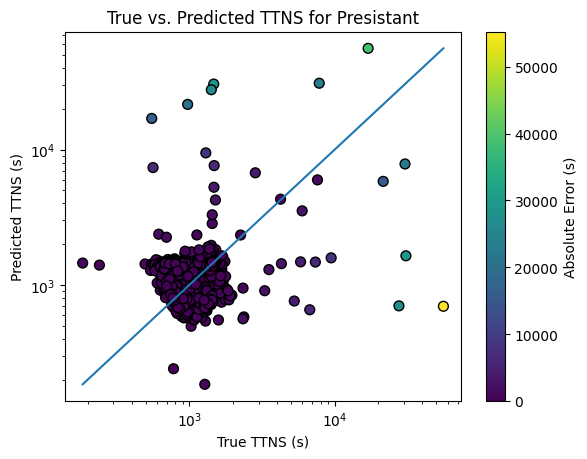

In [12]:
# Baseline Analysis:Median

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median")
plt.xscale('log')
plt.yscale('log')
plt.show()

#Persistnat 
y_test_secs = y_test[1:] #Taking it out of log scale
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Presistant")
plt.xscale('log')
plt.yscale('log')
plt.show()